In [1]:
import import_helper
import_helper.add_models()
# import model.nondim_kondo_model as nondim_kondo

import numpy as np
import matplotlib.pyplot as plt

Production term for the dimensionless model:
\begin{align}
    \tilde{F}_{\tilde{A}}(\tilde{A}, \tilde{I}) &= \max \left \{0, \min \left \{ \tilde{A}^{\max}, a^*_A \tilde{A} + b^*_A \tilde{I} + c^*_A \right \} \right \}, \\
    \tilde{F}_{\tilde{I}}(\tilde{A}, \tilde{I}) &= \max \left \{0, \min \left \{ \tilde{I}^{\max}, a^*_I \tilde{A} + b^*_I \tilde{I} + c^*_I \right \} \right \}. \\
\end{align}

The equilibrium points are
\begin{align}
    A_{eq} &= \frac{-b_Ac_I - c_A(\kappa -b_I)}{(a_A-1)(\kappa-b_I) + b_Aa_I}, \\
    I_{eq} &= \frac{c_I(a_A-1) - a_Ic_A}{(a_A-1)(\kappa-b_I) + b_Aa_I}.
\end{align}

In [2]:
# functions 
def fixed_points(aA, bA, cA, dA, aI, bI, cI, dI):
    """Take parameter values and find fixed points values"""
    denom = (aA - dA) * (dI - bI) + bA * aI
    Aeq = (-bA * cI - cA * (dI - bI)) / denom
    Ieq = (cI * (aA - dA) - aI * cA) / denom
    return Aeq, Ieq

def production_function(A, I, aA, bA, cA, aI, bI, cI, Amax, Imax):
    """Dimensionless production function"""
    production_A = aA * A + bA * I + cA
    production_I = aI * A + bI * I + cI
    prod_A = np.maximum(0, np.minimum(Amax, production_A))
    prod_I = np.maximum(0, np.minimum(Imax, production_I))
    return prod_A, prod_I

In [3]:
# parameters
aA = 8/3
bA = -8/3
cA = 1/18 #1/6 
dA = 1 # same as kappa
aI = 10/3
bI = 0
cI = -1/6 #-1/2 
dI = 2
Amax = 2
Imax = 5

fixed_points_params = {"aA":aA, "bA":bA, "cA":cA, "dA":dA, 
                       "aI":aI, "bI":bI, "cI":cI, "dI":dI}
production_params = {"aA":aA, "bA":bA, "cA":cA,
                     "aI":aI, "bI":bI, "cI":cI,
                     "Amax":Amax, "Imax":Imax}


In [4]:
A_eq, I_eq = fixed_points(**fixed_points_params)

In [5]:
print(A_eq, I_eq)

0.09999999999999999 0.08333333333333331


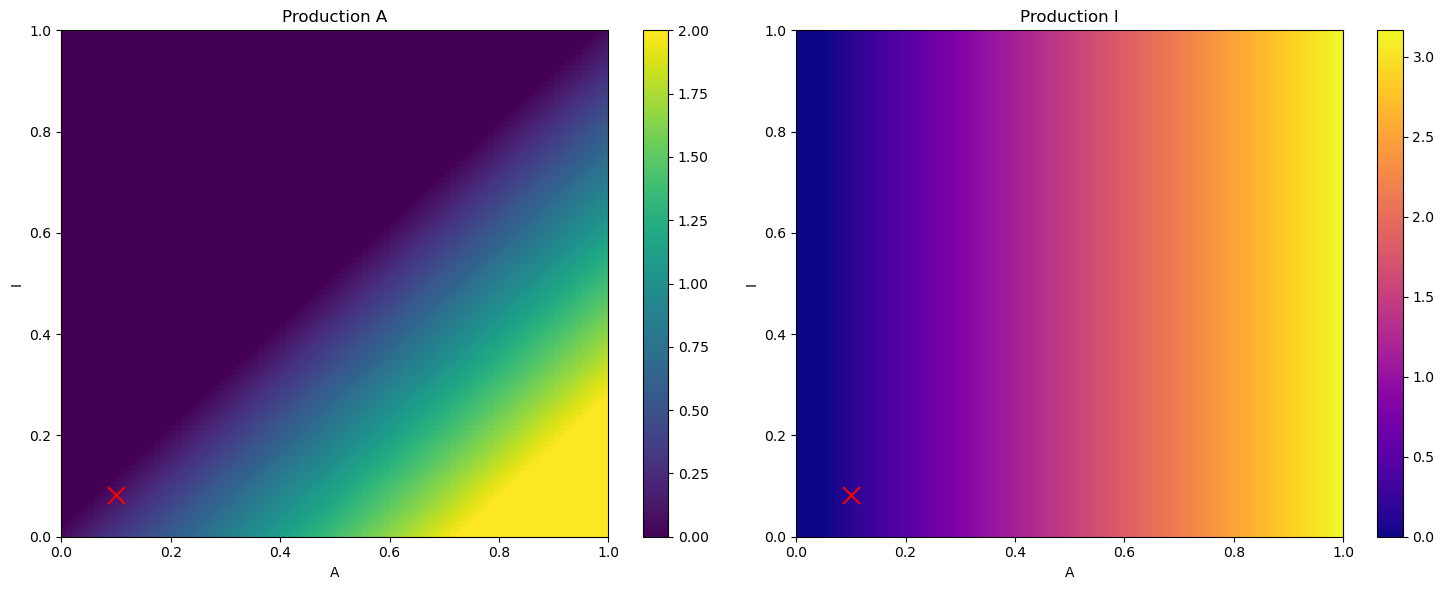

In [10]:
# Create grid
A_vals = np.linspace(0, 1, 100)
I_vals = np.linspace(0, 1, 100)
A_grid, I_grid = np.meshgrid(A_vals, I_vals)

# Compute production values
prod_A, prod_I = production_function(A_grid, I_grid, **production_params)

# Plot heatmaps
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

c1 = axs[0].imshow(prod_A, origin='lower', extent=(0, 1, 0, 1), aspect='auto', cmap='viridis')
axs[0].scatter(A_eq, I_eq, marker="x", color="red", s=150)
axs[0].set_title('Production A')
axs[0].set_xlabel('A')
axs[0].set_ylabel('I')
fig.colorbar(c1, ax=axs[0])

c2 = axs[1].imshow(prod_I, origin='lower', extent=(0, 1, 0, 1), aspect='auto', cmap='plasma')
axs[1].scatter(A_eq, I_eq, marker="x", color="red", s=150)
axs[1].set_title('Production I')
axs[1].set_xlabel('A')
axs[1].set_ylabel('I')
fig.colorbar(c2, ax=axs[1])

plt.tight_layout()
plt.show()